# Train ANN Regressor

We train a feed-forward ANN to approximate the properties of the cross section and the utilization.

Remarks:
- The target features are very different in magnitude. To make up for this, we scale the targets for the time of training and the ANN has a frozen tail that applies inverse scaling in production.
The reason why this was not a problem for  sklearn linear regression models is that sklearn.linear_model.LinearRegression solves ordinary least squares exactly (via SVD/QR), not by gradient descent. It’s scale-invariant w.r.t. feature/target magnitudes for the solution (only the numeric value of the loss changes). Furthermore, the equations for the separate targets are completely decoupled. On the other side, the PyTorch ANN uses gradient-based training. With multi-output targets of very different scales, the largest target dominates the MSE gradients, so the network mostly optimizes that one and can look “stuck”. The equations are also coupled, since the model has only one set of weights that must work for all the targets at the same time.

## Imports and Input Data

In [282]:
import json
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
from typing import Optional
from tqdm import tqdm

In [283]:
config_file_path = "config_rhs.json"
data_file_path = "data_rhs.csv"
model_file_path = "ANN_regressor.pt"

In [284]:
with open(config_file_path, "r") as f:
    config: dict = json.load(f)

In [285]:
# Load section data
section_data = config["section"]

section_variables = []
for p in section_data["params"].keys():
    if section_data["params"][p]["variable"]:
        section_variables.append(p)
        
load_components = ["n", "mxx", "myy", "vx", "vy", "mzz"]
predictor_columns = section_variables + load_components

target_columns = ["utilization", "area", "ixx", "iyy", "ixy", "g_eff"]

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda:0")
else:
    device = torch.device("cpu")
print(f"Using device: {device}")

Using device: mps


In [286]:
df = pd.read_csv(data_file_path)
df = df.dropna()
assert df.isnull().sum().max() == 0, "DataFrame still contains NaN values after dropping."
print("Number of rows after dropping NaNs:", len(df))
df.head(100)

Number of rows after dropping NaNs: 3720


,d,b,t,r_out,n_r,n,mxx,myy,vx,vy,mzz,area,ixx,iyy,ixy,g_eff,utilization,section_param_id,section_type
0,292.940338,184.123599,16.722934,17.628862,4,-688877.841108,-1.312324e+07,2.412614e+06,-115170.575087,13682.531592,1.153415e+07,14527.235375,3.200690e+13,1.520191e+13,-0.265625,76923.076923,0.322426,0,rectangular_hollow_section
1,292.940338,184.123599,16.722934,17.628862,4,354570.903962,-2.555486e+07,-5.432602e+06,41320.270385,152295.668465,-2.124411e+07,14527.235375,3.200690e+13,1.520191e+13,-0.265625,76923.076923,0.352120,0,rectangular_hollow_section
2,292.940338,184.123599,16.722934,17.628862,4,-487911.441850,-6.665061e+06,2.604899e+07,-240323.071707,238398.799619,-1.857385e+07,14527.235375,3.200690e+13,1.520191e+13,-0.265625,76923.076923,0.762931,0,rectangular_hollow_section
3,292.940338,184.123599,16.722934,17.628862,4,-48213.704668,2.253705e+07,1.034981e+07,-233498.377101,-168306.320838,1.210748e+07,14527.235375,3.200690e+13,1.520191e+13,-0.265625,76923.076923,0.647851,0,rectangular_hollow_section
4,292.940338,184.123599,16.722934,17.628862,4,-957990.414679,-5.910821e+06,9.593818e+06,17546.913768,-174641.502762,1.074127e+07,14527.235375,3.200690e+13,1.520191e+13,-0.265625,76923.076923,0.274913,0,rectangular_hollow_section
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,101.813572,109.591089,13.930502,10.252011,4,-564928.616997,1.622176e+07,2.614503e+07,175814.240826,-39441.351069,2.216032e+07,5008.606822,1.327432e+12,1.502990e+12,0.010254,76923.076923,1.077578,5,rectangular_hollow_section
116,101.813572,109.591089,13.930502,10.252011,4,-312441.445315,1.047845e+07,2.782598e+07,-214745.990821,29139.577702,-1.595956e+07,5008.606822,1.327432e+12,1.502990e+12,0.010254,76923.076923,0.945353,5,rectangular_hollow_section
117,101.813572,109.591089,13.930502,10.252011,4,160602.876633,1.547682e+07,-1.796579e+07,203558.739351,-52621.391867,-2.141584e+07,5008.606822,1.327432e+12,1.502990e+12,0.010254,76923.076923,1.166064,5,rectangular_hollow_section
118,101.813572,109.591089,13.930502,10.252011,4,-261612.747473,5.105223e+06,1.758743e+07,243210.142476,-234825.931062,-6.338786e+06,5008.606822,1.327432e+12,1.502990e+12,0.010254,76923.076923,1.224112,5,rectangular_hollow_section


## Preprocess Input Data

In [287]:
X = df[predictor_columns]
y = df[target_columns]
X.shape, y.shape

((3720, 10), (3720, 6))

In [288]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42, stratify=df["section_param_id"]
)
print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (2492, 10)
Testing data shape: (1228, 10)


In [289]:
scaler = StandardScaler()
scaler.fit(X_train)
feature_mean = scaler.mean_          # shape (number of features,)
feature_std  = scaler.scale_         # shape (number of features,)
print("Feature means:", feature_mean)
print("Feature std devs:", feature_std)

Feature means: [ 1.65813305e+02  1.71129893e+02  1.06149874e+01  1.37486086e+01
  6.81400731e+03 -3.92805238e+04  1.07305856e+05 -6.96406744e+02
 -1.24367486e+03  3.65693342e+05]
Feature std devs: [7.89362559e+01 7.55619484e+01 5.06570778e+00 3.57287537e+00
 6.06771828e+05 1.69840720e+07 1.74757740e+07 1.58825709e+05
 1.61072256e+05 1.29259369e+07]


In [290]:
scaler = StandardScaler()
scaler.fit(y_train)
target_mean = scaler.mean_          # shape (number of targets,)
target_std  = scaler.scale_         # shape (number of targets,)
print("Target means:", target_mean)
print("Target std devs:", target_std)

Target means: [ 1.35190822e+00  6.38947150e+03  6.69352833e+12  6.97526846e+12
 -3.02305880e-03  7.69230769e+04]
Target std devs: [1.70360953e+00 3.76527837e+03 7.50039576e+12 7.48566787e+12
 5.67398396e-02 1.00000000e+00]


In [291]:
train_dataset = TensorDataset(
    torch.tensor(X_train.values, dtype=torch.float32),
    torch.tensor(y_train.values, dtype=torch.float32),
)

test_dataset = TensorDataset(
    torch.tensor(X_test.values, dtype=torch.float32),
    torch.tensor(y_test.values, dtype=torch.float32),
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, drop_last=False,)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, drop_last=False)

print("Shape of train data: ", train_dataset[:][0].shape)
print("Shape of test data: ", test_dataset[:][0].shape)

Shape of train data:  torch.Size([2492, 10])
Shape of test data:  torch.Size([1228, 10])


## Create Model

In [ ]:
class Standardize(nn.Module):
    """
    Standardize input features using precomputed mean and standard deviation.

    This module performs feature-wise standardization according to:
        y = (x - mean) / (std + eps)

    The transformation uses fixed statistics (non-trainable buffers) derived
    from the training dataset, ensuring consistent scaling during both
    training and inference.

    Parameters
    ----------
    mean : array-like of shape (D,)
        The mean of each feature computed from the training data.
    std : array-like of shape (D,)
        The standard deviation of each feature computed from the training data.
    eps : float, default=1e-6
        Small constant added to the denominator to prevent division by zero or
        numerical overflow when `std` contains very small values.

    Attributes
    ----------
    mean : torch.Tensor
        Non-trainable tensor buffer containing the feature-wise means.
    std : torch.Tensor
        Non-trainable tensor buffer containing the feature-wise standard deviations.
        Zero or near-zero values are replaced with 1.0 to avoid division by zero.
    eps : float
        Small constant for numerical stability.

    Examples
    --------
    >>> import torch
    >>> mean = [0.5, 1.0, 2.0]
    >>> std = [0.1, 0.2, 0.0]
    >>> layer = Standardize(mean, std)
    >>> x = torch.tensor([[0.6, 1.4, 2.0]])
    >>> layer(x)
    tensor([[1.0000, 2.0000, 0.0000]])

    Notes
    -----
    - Unlike BatchNorm, this transformation uses fixed statistics computed
      offline (e.g., from the training dataset) and does not adapt during training.
    - The `eps` parameter provides additional stability for features with very
      small standard deviations.

    """

    def __init__(self, mean: np.array, std: np.array, eps:float=1e-6):
        super().__init__()
        
        # Convert to torch tensors
        mean = torch.as_tensor(mean, dtype=torch.float32)
        std = torch.as_tensor(std, dtype=torch.float32)

        # Protect against zero-variance columns (constant features)
        std = torch.where(std == 0, torch.ones_like(std), std)

        # Register as buffers (non-trainable but moved with .to(device))
        self.register_buffer("mean", mean)
        self.register_buffer("std", std)
        
        self.eps = eps

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Apply standardization to the input tensor.

        Parameters
        ----------
        x : torch.Tensor of shape (N, D)
            Input data to standardize.

        Returns
        -------
        torch.Tensor of shape (N, D)
            Standardized output tensor, computed as
            (x - mean) / (std + eps).
        """
        return (x - self.mean) / (self.std + self.eps)


class BaseRegressor(nn.Module):
    """
    Fully connected feedforward neural network for regression tasks.

    The model applies an internal feature-wise standardization layer followed by
    several linear layers with ReLU activations and dropout regularization.

    Parameters
    ----------
    feature_mean : array-like of shape (D,)
        Mean of each feature in the training data. Used for internal standardization.
    feature_std : array-like of shape (D,)
        Standard deviation of each feature in the training data. Used for internal standardization.
    dim_in : int, default=-1
        Number of input features. If -1, this defaults to the length of `feature_mean`.
    dim_hidden : int, default=-1
        Number of hidden features per layer. If -1, this defaults to the number of input features.
    dim_out : int
        Number of output features (dimensionality of the regression target). Must be a positive integer.
    n_hidden : int, default=5
        Number of hidden layers in the network.
    dropout : float, default=0.1
        Dropout probability applied after each hidden layer to reduce overfitting.

    Attributes
    ----------
    standardizer : Standardize
        Layer that standardizes input features using fixed mean and standard deviation.
    net : torch.nn.Sequential
        Sequential container holding multiple fully connected layers, ReLU activations,
        and dropout layers.

    Notes
    -----
    - The network consists of five hidden layers (each followed by ReLU and dropout).
    - This design is suitable for regression tasks.
    - The feature standardization performed by the `Standardize` layer ensures that
      the model receives inputs on a consistent scale during both training and inference.

    Examples
    --------
    >>> import numpy as np
    >>> import torch
    >>> train_mean = np.array([0.5, 1.0, 2.0])
    >>> train_std = np.array([0.1, 0.2, 0.3])
    >>> model = Model(train_mean, train_std, n_out=2)
    >>> x = torch.tensor([[0.6, 1.4, 2.0]])
    >>> output = model(x)
    >>> print(output.shape)
    torch.Size([1, 2])
    """

    def __init__(
        self, 
        feature_mean: Optional[np.array]=None, 
        feature_std: Optional[np.array]=None,
        dim_in: int = -1,
        dim_out: int = -1, 
        dim_hidden: int = -1,
        n_hidden: int = 5,
        dropout: float = 0.1
    ):
        super().__init__()

        assert dim_out > 0, "The number of output features (dim_out) must be a positive integer."

        # Internal standardization layer
        self.standardizer = Standardize(feature_mean, feature_std)

        if dim_in == -1:
            dim_in = len(self.standardizer.mean)
        
        if dim_hidden == -1:
            dim_hidden = dim_in

        # Input layer
        layers = [
            nn.Linear(dim_in, dim_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
        ]
        # Hidden layers
        for _ in range(n_hidden):
            layers.extend([
                nn.Linear(dim_hidden, dim_hidden),
                nn.ReLU(),
                nn.Dropout(dropout),
            ])
        # Output layer
        layers.append(nn.Linear(dim_hidden, dim_out))
        
        # Combine all layers into a sequential container
        self.net = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Perform a forward pass through the network.

        Parameters
        ----------
        x : torch.Tensor of shape (N, D)
            Input feature tensor, where N is the batch size and D is the number of features.

        Returns
        -------
        torch.Tensor of shape (N, K)
            Output logits for each input sample. K is the number of output features.
        """
        x = self.standardizer(x)
        return self.net(x)


model = BaseRegressor(
    feature_mean=feature_mean, 
    feature_std=feature_std,
    dim_in=len(predictor_columns),
    dim_hidden=int(2*len(predictor_columns)), 
    dim_out=len(target_columns),
    n_hidden=2,
    dropout=0.1
)
model = model.to(device)

## Train Model

In [293]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-3)

In [294]:
# --- Training configuration ---
n_epochs = 200
patience = 15  # epochs to wait for improvement before early stopping

# Suppose you computed these on the TRAIN set (shape [T])
mu  = torch.tensor(target_mean, dtype=torch.float32).to(device)
std = torch.tensor(target_std,  dtype=torch.float32).clamp_min(1e-12).to(device)

def scale_targets(y):   return (y - mu) / std
def unscale_targets(z): return z * std + mu

# Stuff to store
train_losses = np.zeros(n_epochs)
test_losses = np.zeros(n_epochs)

best_test_loss = float('inf')
best_state_dict = None
epochs_no_improve = 0

# Learning rate (LR) scheduler (reduces LR if test loss plateaus)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

pbar = tqdm(total=n_epochs)

# --- Training loop ---
for epoch in range(n_epochs):
    
    model.train()  # set model to training mode (enables dropout, etc.)
    batch_train_losses = []

    for inputs, targets in train_loader:
        # Move data to GPU
        inputs, targets = inputs.to(device), targets.to(device)
        targets_scaled = scale_targets(targets) 

        # Reset gradients
        optimizer.zero_grad()

        # Forward pass
        outputs_scaled = model(inputs)
        loss = criterion(outputs_scaled, targets_scaled)

        # Backpropagation and update
        loss.backward()
        optimizer.step()

        batch_train_losses.append(loss.item())

    # Compute mean training loss for this epoch
    train_loss = np.mean(batch_train_losses)

    # --- Validation/Test loop ---
    model.eval()  # set to evaluation mode (disables dropout, etc.)
    batch_test_losses = []

    with torch.no_grad():  # no gradient tracking during evaluation
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            targets_scaled = scale_targets(targets) 
            outputs_scaled = model(inputs)
            loss = criterion(outputs_scaled, targets_scaled)
            batch_test_losses.append(loss.item())

    test_loss = np.mean(batch_test_losses)

    # Store epoch losses
    train_losses[epoch] = train_loss
    test_losses[epoch] = test_loss

    # Step the scheduler (monitors validation loss)
    scheduler.step(test_loss)

    # --- Early stopping logic ---
    if test_loss < best_test_loss - 1e-4:
        best_test_loss = test_loss
        best_state_dict = model.state_dict()  # keep a copy of the best model
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            tqdm.write(f"Early stopping at epoch {epoch+1}")
            break

    # Logging
    pbar.set_description(
        f"Epoch {epoch+1}/{n_epochs} | "
        f"Train Loss: {train_loss:.4f} | Test Loss: {test_loss:.4f}"
    )
    pbar.update(1)

# --- Restore best model weights ---
if best_state_dict is not None:
    model.load_state_dict(best_state_dict)
    tqdm.write(f"✅ Restored best model from epoch {epoch+1 - epochs_no_improve}")
    # train_losses = train_losses[:(epoch+1 - epochs_no_improve)]
    # test_losses = test_losses[:(epoch+1 - epochs_no_improve)]

pbar.close()

Epoch 154/200 Train Loss: 0.1885 | Test Loss: 0.1258:  77%|███████▋  | 154/200 [00:42<00:12,  3.61it/s]

Early stopping at epoch 155
✅ Restored best model from epoch 140


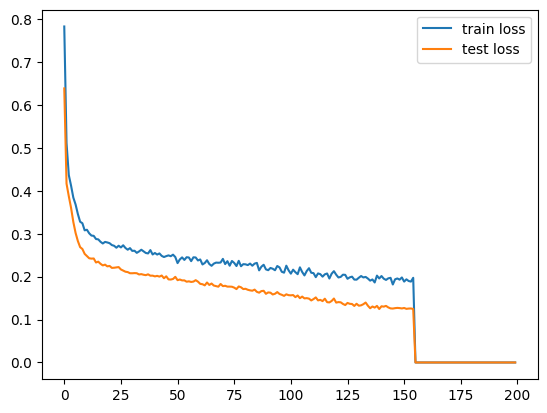

In [295]:
# Plot the train loss and test loss per iteration
plt.plot(train_losses, label='train loss')
plt.plot(test_losses, label='test loss')
plt.legend()
plt.show()

## Save Model

In [296]:
class InverseStandardize(nn.Module):
    def __init__(self, mu: torch.Tensor, std: torch.Tensor):
        super().__init__()
        self.register_buffer('mu',  mu.clone())
        self.register_buffer('std', std.clone())
    def forward(self, z):                # z = scaled preds
        return z * self.std + self.mu    # unscaled preds
    
deployed_model = nn.Sequential(model, InverseStandardize(mu, std))
scripted = torch.jit.script(deployed_model.eval())
scripted.save(model_file_path)

In [301]:
# test if model works after being reloaded
loaded = torch.jit.load(model_file_path, map_location=device)
loaded.eval()
loaded(torch.tensor(X_test.values[:5], dtype=torch.float32).to(device));